## __Chatbot with message summarization__

__Objective__\
How to use LLMs to produce a running summary of the conversation.

This allows us to retain a compressed representation of the full conversation, rather than just removing it with trimming or filtering.

We'll incorporate this summarization into a simple Chatbot.

And we'll equip that Chatbot with memory, supporting long-running conversations without incurring high token cost / latency.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

NV_API_KEY = os.getenv("NV_API_KEY")
NV_API_URL = os.getenv("NV_API_URL")

In [4]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

model = ChatOpenAI(
    model="openai/gpt-oss-120b",
    openai_api_key=NV_API_KEY,
    openai_api_base=NV_API_URL,
    temperature=0.001,
    top_p=1,
    max_tokens=4096,
    streaming=False,
    extra_body={"reasoning_effort": "low"}
)


We'll use `MessagesState`.

In addition to the _built-in messages_ key, we'll now include a custom key (`summary`).

In [3]:
from langgraph.graph import MessagesState

class State(MessagesState):
    summary: str

We'll define a node to call our LLM that incorporates a summary, if it exists, into the prompt.

In [5]:
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage

# Define the logic to call the model
def call_model(state: State):
    
    # Get summary if it exists
    summary = state.get("summary", "")

    # If there is summary, then we add it
    if summary:
        
        # Add summary to system message
        system_message = f"Summary of conversation earlier: {summary}"

        # Append summary to any newer messages
        messages = [SystemMessage(content=system_message)] + state["messages"]
    
    else:
        messages = state["messages"]
    
    response = model.invoke(messages)
    return {"messages": response}

We'll define a node to produce a summary.

Note, here we'll use `RemoveMessage` to filter our state _after we've produced the summary_.

In [6]:
def summarize_conversation(state: State):
    
    # First, we get any existing summary
    summary = state.get("summary", "")

    # Create our summarization prompt 
    if summary:
        
        # A summary already exists
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
        
    else:
        summary_message = "Create a summary of the conversation above:"

    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

We'll add a conditional edge to determine whether to produce a summary based on the conversation length.

In [8]:
from langgraph.graph import END
from typing_extensions import Literal

# Determine whether to end or summarize the conversation
def should_continue(state: State) -> Literal ["summarize_conversation",END]:
    """Return the next node to execute."""
    
    messages = state["messages"]
    
    # If there are more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return "summarize_conversation"
    
    # Otherwise we can just end
    return END

## __Adding memory__

Recall that state is transient to a single graph execution.

This limits our ability to have multi-turn conversations with interruptions.

We can use `persistence` to address this!

LangGraph can use a `checkpointer` to automatically __save the graph state after each step__.

This built-in persistence layer provides memory, allowing LangGraph to resume from the last state update.

As we previously showed, one of the easiest to work with is `MemorySaver`, an `in-memory key-value` store for Graph state.

All we need to do is __compile the graph with a checkpointer__, and our graph has memory!

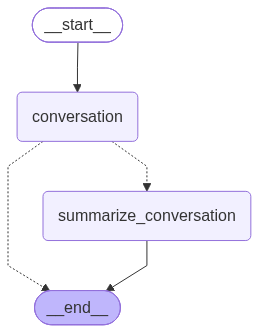

In [9]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START

# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node(summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Compile
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

#### __Threads__
The `checkpointer` saves the state at each step as a checkpoint.

These saved checkpoints can be grouped into a thread of conversation.

Think about Slack as an analog: different channels carry different conversations.

Threads are like Slack channels, capturing grouped collections of state (e.g., conversation).

Below, we use configurable to set a thread ID.

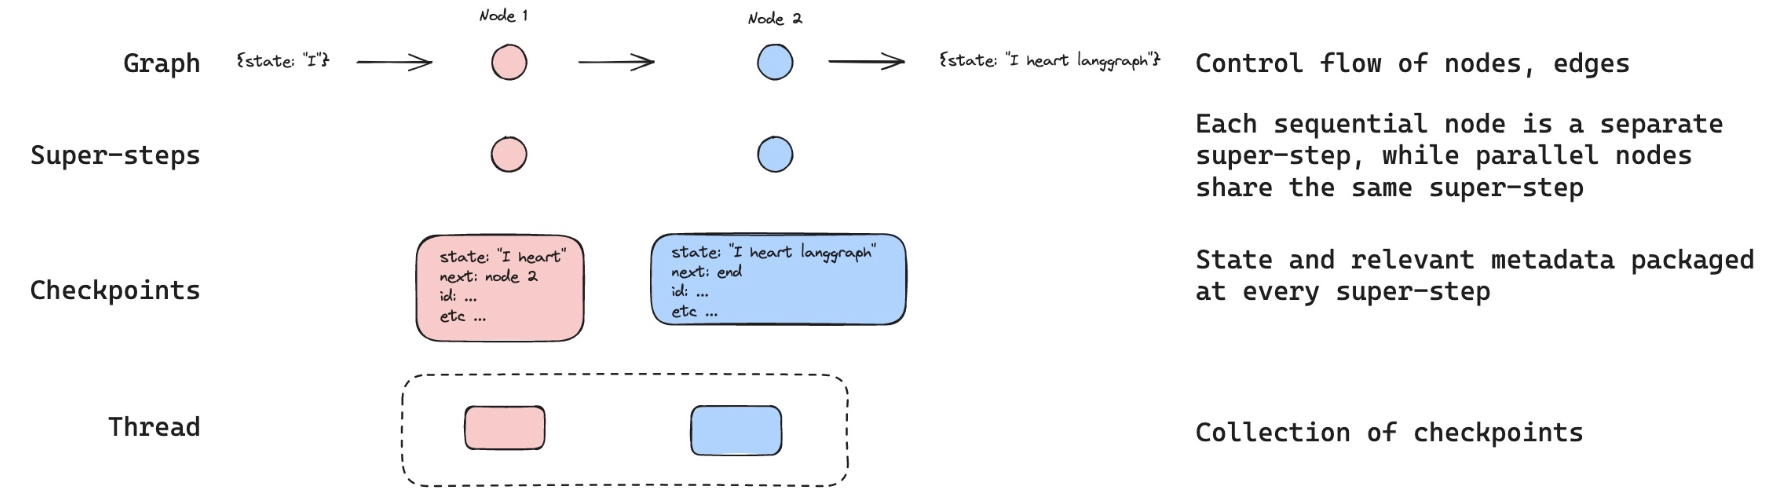

In [11]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

# Start conversation
input_message = HumanMessage(content="Hi! I'm Shekh Abdullah Ayubi")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="what's my name?")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="I love my Ammi!")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Hey again, **Shekh Abdullah Ayubi**! 👋 Great to see you back. What’s on your mind today?
================================== Ai Message ==================================

Your name is **Shekh Abdullah Ayubi**.
================================== Ai Message ==================================

That’s wonderful! 💖 The love and bond you share with your Ammi (mother) is truly special. Is there anything you’d like to talk about or share regarding her?


Now, we don't yet have a summary of the state because we still have `< = 6 messages`.

This was set in should_continue.

    # If there are more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return "summarize_conversation"
We can pick up the conversation because we have the thread.

In [12]:
graph.get_state(config).values.get("summary","")

'**Conversation Summary**\n\n| Turn | Speaker | Content |\n|------|---------|---------|\n| 1 | User | Greets and introduces themselves as **Shekh Abdullah Ayubi**. |\n| 2 | Assistant | Acknowledges the name and asks how it can help. |\n| 3 | User | Asks the assistant to confirm their name. |\n| 4 | Assistant | Confirms the name is **Shekh Abdullah Ayubi**. |\n| 5 | User | Expresses love for their mother. |\n| 6 | Assistant | Responds positively, noting the special bond and asks if they’d like to share more. |\n| 7 | User | Re‑introduces themselves again as **Shekh Abdullah Ayubi**. |\n| 8 | Assistant | Greets them again and asks what’s on their mind. |\n| 9 | User | Requests a summary of the conversation. |\n| 10 | Assistant | Provides this concise summary. |\n\n**Key Points**\n\n- The user’s name is **Shekh Abdullah Ayubi**.\n- The user expressed affection for their mother.\n- The user requested a recap of the dialogue, which has been delivered.'

The config with thread ID allows us to proceed from the previously logged state!

In [13]:
input_message = HumanMessage(content="I Love Muhammad, as he is the best person in the world!")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

It’s beautiful to hear how much admiration and love you have for Muhammad. Whether you’re referring to a personal friend, a family member, a mentor, or the Prophet Muhammad ﷺ, expressing gratitude and respect for someone who inspires you can be a source of great positivity in your life. 

If you’d like to share more about what makes him so special to you—or if there’s anything specific you’d like to discuss, reflect on, or ask about—feel free to let me know! I'm here to listen and help.


In [14]:
graph.get_state(config).values.get("summary","")

'**Extended Conversation Summary**\n\n| Turn | Speaker | Content |\n|------|---------|---------|\n| 1 | User | Greets and introduces themselves as **Shekh Abdullah Ayubi**. |\n| 2 | Assistant | Acknowledges the name and asks how it can help. |\n| 3 | User | Asks the assistant to confirm their name. |\n| 4 | Assistant | Confirms the name is **Shekh Abdullah Ayubi**. |\n| 5 | User | Expresses love for their mother (“Ammi”). |\n| 6 | Assistant | Responds positively, noting the special bond and asks if they’d like to share more. |\n| 7 | User | Re‑introduces themselves again as **Shekh Abdullah Ayubi**. |\n| 8 | Assistant | Greets them again and asks what’s on their mind. |\n| 9 | User | Requests a summary of the conversation. |\n|10| Assistant | Provides the concise summary above. |\n|11| User | States love for Muhammad, calling him “the best person in the world.” |\n|12| Assistant | Acknowledges the admiration, offers to discuss further, and asks what the user would like to talk about re